In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
data = pd.read_csv("iris.csv")

In [ ]:
X = data.iloc[:, :-1]   # Features
y = data.iloc[:, -1]    # Target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)


SVC(kernel='linear')

In [ ]:
y_pred_linear = svm_linear.predict(X_test)


In [ ]:
accuracy_score = accuracy_score(y_test, y_pred_linear)
confusion_matrix = confusion_matrix(y_test, y_pred_linear)

In [ ]:
print("Linear Kernel Accuracy:", accuracy_score)
print("Confusion Matrix:\n", confusion_matrix)

Linear Kernel Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

SVC()

In [ ]:
y_pred_rbf = svm_rbf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

RBF Kernel Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


SVM ON DRUG DATASET



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

In [ ]:
data = pd.read_csv("letter-recognition.csv")


In [ ]:
X = data.iloc[:, 1:]   # Features
y = data.iloc[:, 0]    # Target (A–Z)

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9305
Confusion Matrix:
 [[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0   0   0   0   0   0   0
    0   0   0   0 

In [ ]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=range(26))

In [ ]:
y_prob = model.predict_proba(X_test)

In [ ]:
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_prob[:, 0])
roc_auc = auc(fpr, tpr)

print("AUC Score (Class A):", roc_auc)

AUC Score (Class A): 0.99994074580123


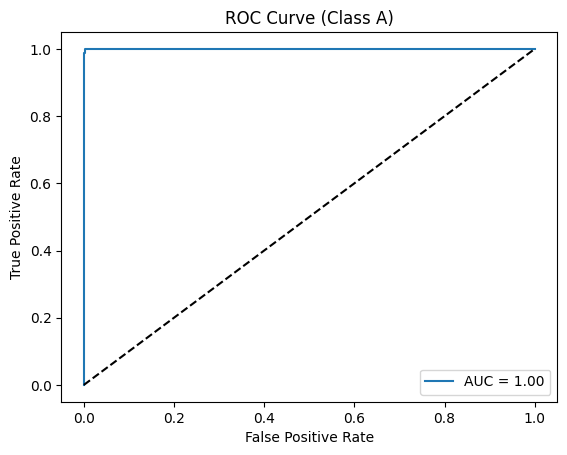

In [ ]:
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class A)")
plt.legend()
plt.show()